***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [5. 成像](5_0_introduction.ipynb)
    * 上一节： [5.2 采样函数与点扩散函数](5_2_sampling_functions_and_psfs.ipynb) 
    * 下一节： [5.4 脏图像与可见度权重](5_4_imaging_weights.ipynb)

***


导入标准模块:

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, Image, display, clear_output
except ImportError:
    def HTML(*args, **kwargs):
        return None

    def Image(*args, **kwargs):
        return None

    def display(*args, **kwargs):
        return None

    def clear_output(*args, **kwargs):
        return None

NOTEBOOK_DIR = Path("5_Imaging") if Path("5_Imaging").exists() else Path(".")
NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()
FIGURE_DIR = NOTEBOOK_DIR / "figures"
STYLE_PATH = NOTEBOOK_DIR.parent / "style" / "course.css"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))


def show_image(name, **kwargs):
    return Image(filename=str(FIGURE_DIR / name), **kwargs)


if STYLE_PATH.exists():
    try:
        HTML(STYLE_PATH.read_text(encoding="utf-8"))
    except Exception:
        pass

导入本节所需的专用模块:

In [ ]:
import AA_filter

## 5.3 FFT 中的网格化与去网格化 <a id='imaging:sec:gridding'></a>


上一节中我们已经介绍了若干采样函数。这些采样函数本身都是离散的，可以直接显示为图像，也就是由等大小像素组成的规则网格。对于这样的规则采样数据，我们可以使用快速傅里叶变换（Fast Fourier Transform, FFT）来完成变换。之所以称为“快速”，是因为 FFT 相比直接傅里叶变换（Direct Fourier Transform, DFT）在计算上高效得多。

为了说明这种效率差异，假设图像共有 $N^2$ 个像素，那么 FFT 的计算量大约为 $2N^2\log(N)$。而 DFT 的复杂度还取决于可见度数量 $M$：对于每个像素，都需要对全部 $M$ 个测量值进行复指数和乘法运算，因此总计算量约为 $N^2M$，而通常这里又有 $M\approx N^2$。具体地说，DFT 会根据下式计算每个像素的亮度：

\begin{equation}
 I(l,m) = \sum_{k=0}^{M-1}V_k(u,v)e^{2\pi i (lu+mv)}\text{，其中 }V_k\text{ 表示望远镜获得的 }M\text{ 个测量值}
\end{equation}

由此可以看出，随着基线数量和观测时间增加，FFT 的优势会越来越明显。不幸的是，射电干涉仪并不会在规则间隔的位置上采样，因此我们不能直接对原始观测可见度使用 FFT。若想使用 FFT，就必须先把原始观测数据重新采样到规则间隔的网格点上。这个重新采样过程称为“网格化”（gridding），而它的逆过程则称为“去网格化”（degridding），这正是本节的主题。

之所以要做网格化和去网格化，核心原因就是：这样才能利用 FFT，以远快于 DFT 的速度进行成图和预测。

后面还会看到，一些 $uv$ 空间中的去卷积算法，例如 Cotton-Schwab 的主循环/次循环算法，需要把图像空间中的源重新转换回不规则的测量空间。因此必须使用精确的去网格化操作，把规则采样的可见度重新插值回对应的 $uv$ 轨迹。

除了重采样问题，FFT 方法还会带来“混叠”（aliasing）问题。FFT 默认输入信号，也就是这里的空间频率域，是周期性的。因此，经过重采样并做逆 FFT 得到的图像，往往会表现出规则间隔的周期性重复，例如靠近图像顶部的源会在底部再次出现。为抑制这种混叠，我们必须引入滤波器，只让视场范围内的信号参与有效重建。混叠的根本原因在于，可见度是在网格上按奈奎斯特率进行采样的（见[$\S$ 2.9 &#10142;](../2_Mathematical_Groundwork/2_9_sampling_theory.ipynb)）。


### 5.3.1 图像分辨率与像素大小


当我们通过傅里叶变换（无论是 DFT 还是 FFT）由可见度生成图像时，需要先指定两个参数：像素分辨率，以及图像大小或视场大小（具体取决于所使用的成像程序）。

对于一个 $N_l \times N_m$ 的二维图像，若视场满足小角近似，并且每个像素的角分辨率为 $(\Delta \theta_l, \Delta \theta_m)$，则回忆前面所用的表示方式，图像大小为 $l' = \cos{\theta_l}$、$m' = \cos{\theta_m}$，其分辨率为 $\Delta l = \cos{\Delta \theta_l}$、$\Delta m = \cos{\Delta \theta_m}$。在小角近似下有 $\Delta l \sim \Delta \theta_l$、$\Delta m \sim \Delta \theta_m$。

虽然很多成像程序在实践中允许一定程度上超出小角近似，但这种近似仍然是基础。通常会通过某种非线性坐标映射，把球面坐标上的一点投影到二维平面上。在射电干涉测量中，最常见的就是 SIN 投影。关于不同坐标投影方法的讨论，可参考 [<cite data-cite='Greisen1994'>AIPS Memo 27</cite> &#10548;](ftp://ftp.aoc.nrao.edu/pub/software/aips/TEXT/PUBL/AIPSMEMO27.PS)。

若给定目标分辨率 $(\Delta \theta_l, \Delta \theta_m)$ 与视场大小 $(\theta_l, \theta_m)$，则图像的像素数（也就是图像大小）为：

$$N_l = \frac{\theta_l}{\Delta \theta_l}$$

$$N_m = \frac{\theta_m}{\Delta \theta_m}$$

我们已经知道，空间频率域中的 $uv$ 采样与图像的像素分辨率之间必须满足奈奎斯特采样关系。因此，对于给定的干涉仪分辨率和图像大小，图像域中的分辨率（或像元大小）可写为：

$$\Delta \theta_l = \frac{1}{2N_l \Delta u} = \frac{1}{2\max{(||\min{u}||,\max{u})}} \text{  radians}$$

$$\Delta \theta_m = \frac{1}{2N_m \Delta v} = \frac{1}{2\max{(||\min{v}||,\max{v})}} \text{  radians}$$

同时，两个域中的像素数量保持一致，也就是 $N_u = N_l$, $N_v = N_m$。

还要注意一点：像素数量最好取 2 的幂，也就是 $N_l = 2^j$, $N_m = 2^k$，其中 $j,k$ 为正整数。这与 FFT 的内部实现有关，当输入长度为 2 的幂时，FFT 的效率最高，而当输入长度为素数时效率通常最低。例如生成一幅 256×256 像素（$2^8 \times 2^8$）的图，通常会比生成 251×251 的图更快，即便前者总像素数还更多。另外，按惯例，干涉测量得到的图像通常都是正方形。


### 5.3.2 网格化与去网格化


正如你所预期的那样，把数据插值到规则间隔坐标上，或者从规则间隔坐标中取回数据，有很多不同的方法。射电成像程序中最常用的一类插值技术，例如 `lwimager` 所采用的，就是“卷积重采样”（convolutional resampling）。在这种技术中，每个可见度都会先乘上某个权重，然后被“涂抹”到其附近一定范围内的规则网格点上。


In [ ]:
show_image("gridding_illustration.png")

*图：在连续的 $uv$ 空间中，每个观测到的可见度都以自己的采样坐标为中心，并乘上某个卷积函数 $C(u,v)$，该函数只在有限“全支持”范围内非零。网格化时，测量值被分配到对应的规则网格点上；去网格化时则反过来，从规则网格中收集数值。所有可见度完成网格化后，再做逆快速傅里叶变换，就得到一张天空图像（脏图）；如果要从天空模型生成一组模拟可见度，则执行相反过程。*


因此，每个网格点的值，本质上是其附近所有可见度经过权重加和后的结果。一维情况下，可以写为：

\begin{equation}
 (\forall a \in \{1,2,\dots,N\}) \mathscr{V}(a\Delta{x}) = \sum_{\substack{
                                                                     i | x_i \geq a\Delta{x}-\text{half support}, \\ 
                                                                     x_i \leq a\Delta{x}+\text{half support}}
                                                                 }{\mathscr{V}(x_i) \, C(a\Delta{x}-x_i)}
\end{equation}


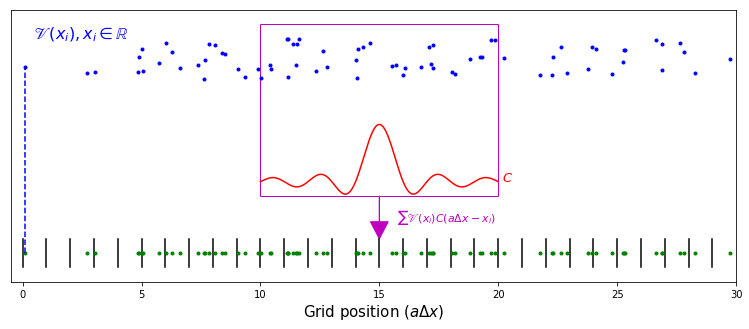

In [13]:
N = 30
dx = 1
a = np.arange(N)
M = 75
tap_pos = (N//2)*dx
conv_hsup = 5*dx
conv_x = np.linspace(-conv_hsup,conv_hsup,1000)
vis_x = np.sort(np.random.rand(M)*N*dx)
vis = 1.5+np.random.rand(M)*0.7 + 0.3
plt.figure(figsize=(13,5))
ax1 = plt.axes()
ax1.axes.get_yaxis().set_visible(False)
for x in a*dx:
    plt.plot([x,x],[-1.5,-1.0],'k')
plt.plot(vis_x,vis,'b.')
plt.plot(vis_x,np.ones([M])*-1.25,'g.')
plt.plot([vis_x[0],vis_x[0]],[-1.25,vis[0]],'b--')
plt.plot(tap_pos+conv_x,np.sinc(conv_x),'r')

plt.arrow(tap_pos-conv_hsup, -0.25, 0, 2.5+0.5, head_width=0.0, head_length=0.0, fc='m', ec='m')
plt.arrow(tap_pos+conv_hsup, -0.25, 0, 2.5+0.5, head_width=0.0, head_length=0.0, fc='m', ec='m')
plt.arrow(tap_pos-conv_hsup, -0.25, conv_hsup*2, 0, head_width=0.0, head_length=0.0, fc='m', ec='m')
plt.arrow(tap_pos-conv_hsup, 2.5+0.25, conv_hsup*2, 0, head_width=0.0, head_length=0.0, fc='m', ec='m')

plt.text(tap_pos+0.75, -0.70, "$\sum{\mathscr{V}(x_i)C(a\Delta{x}-x_i)}$", fontsize=11,color='m')
plt.text(tap_pos+conv_hsup+0.15, 0, "$C$", fontsize=13,color='r')
plt.text(0.5, 2.5, "$\mathscr{V}(x_i),x_i\in\mathbb{R}$", fontsize=16,color='b')
plt.arrow(tap_pos, -0.25, 0, -0.45, head_width=0.75, head_length=0.3, fc='m', ec='m')
plt.ylim(-1.75,3.0)
plt.xlim(-0.5*dx,N*dx)
plt.xlabel("Grid position ($a\Delta{x}$)",fontsize=15)
plt.show()



*图：一维网格化过程示意。x 轴上的绿色圆点表示可见度函数在不规则位置上的采样，红线表示卷积函数 $C$，x 轴上的黑色短线表示规则间隔的网格点。网格点上的值，近似等于可见度函数与卷积函数的卷积结果。*


权重函数 $C$ 可以取很多不同形式，例如线性函数、拉格朗日函数、sinc 函数（以及其各种窗口版本）、高斯函数、修正 B 样条等。

你可能已经注意到，上面的插值表达式和离散卷积非常接近。如果重采样的数据本身就是规则采样的，而卷积函数也正好在这些规则步长上取值，那么它就会退化为普通的离散卷积。不过从严格定义上说，这里并不是一个完全标准的卷积。因此，更准确地说，网格化和去网格化应当被视为离散卷积的近似操作。尽管如此，我们在讨论中仍然沿用通常的卷积符号。

如果你有信号处理背景，可以把网格化和去网格化分别类比为上采样和下采样。网格化时，和传统上采样类似，先在采样点之间填零；只不过这里原始观测点本身并不是规则间隔的。然后再像上采样一样，对这些新填入的零值区域进行赋值，不过赋值方式是把测量值按卷积权重扩散到支持范围内的多个网格点上。


In [ ]:
show_image("oversampled_filter_illustration.png")

*图：一个带填充的过采样滤波器示意图。它具有 3 个网格宽度的全支持区域（即中心值两边各有半支持宽度 1），并且在两端各多填充了一个值。该滤波器采用 5 倍过采样，如图中星号间的间距所示。黑色短竖线表示网格分辨率（$\Delta u$ 或 $\Delta v$）。如果测得的 $uv$ 坐标恰好落在最近网格点上（红点），则编号 6、11、16 的值会被选作插值系数；如果 $uv$ 坐标略微偏离网格点（绿点），则会选用 8、13、18 号系数。可以把这理解为：在原有网格“钉床”之上再覆盖一层更密的钉床，以便在卷积时选到更接近真实位置的插值系数。*


更重要的是，卷积滤波器具有减弱混叠的作用，而这对于 FFT 方法至关重要。根据卷积定理，射电天空的重建图像可以表示为：

\begin{equation}
I_\text{dirty}[l,m] = ([I(l,m)\circ\text{PSF}(l,m)] \, c(l,m))\circ\mathscr{F}\{III\}[l,m]
\end{equation}

Shah 函数的傅里叶变换 $\mathscr{F}\{III\}[l,m]$ 在图像域中表现为一组周期函数。对于一个包含 $M\times N$ 像素的图像来说，与这些周期函数卷积，会导致视场以周期 $M\Delta{\theta_l}$ 和 $N\Delta{\theta_m}$ 重复，也就是混叠。因此，我们希望卷积滤波器的傅里叶变换 $c(l,m)$ 能尽量让下面的比值最大：

\begin{equation}
\frac{\int_\text{FOV} \lvert c(l,m) \rvert^2dS}{\int_{-\infty}^\infty \lvert c(l,m) \rvert^2dS}
\end{equation}

简单来说，就是希望函数 $c$ 只在中央较小区域，也就是视场范围内，尽可能非零，而在视场外迅速衰减。

基于这一点，无论从插值精度还是抗混叠效果考虑，都不建议使用最近邻方法。对去网格化来说，插值精度尤其关键；对网格化来说，抗混叠性能更重要。最近邻插值（旧文献中也叫 cell-summing）只是简单地把落在矩形支持区域内的点直接累加，而不考虑它们距目标点到底有多远。由于这种框函数的傅里叶变换是一个无限延展的 sinc 函数，它的振荡会很慢地衰减，因此无法有效抑制混叠。

因此，卷积型网格化/去网格化通常采用更好的卷积函数，在决定权重时显式考虑网格点与测量 $uv$ 点之间的距离。


In [ ]:
show_image("NN_interpolation_aliasing.png", width=512)

In [ ]:
show_image("AA_kernel_alias_reduction.png", width=512)

*图：两幅由多点源合成得到的图像。上图使用网格累积（最近邻）插值，下图使用简单截断 sinc 函数的卷积重采样。上图中，落在视场外的源被混叠回视场内；下图中，这种混叠被截断 sinc 函数明显抑制。*


下面画出了若干函数傅里叶变换的旁瓣幅度谱。可以看到，框函数对应傅里叶变换的旁瓣要明显高于截断 sinc 或加窗 sinc 之类的函数。


In [ ]:
half_sup = 6
oversample = 15
full_sup_wo_padding = (half_sup * 2 + 1)
full_sup = full_sup_wo_padding + 2 #+ padding
no_taps = full_sup + (full_sup - 1) * (oversample - 1)
taps = np.arange(-no_taps//2,no_taps//2 + 1)/float(oversample)

#unit box
box = np.where((taps >= -0.5) & (taps <= 0.5),
               np.ones([len(taps)]),np.zeros([len(taps)]))

fft_box = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(box))))
#truncated (boxed) sinc
sinc = np.sinc(taps)
fft_sinc = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sinc))))
#gaussian sinc
alpha_1 = 1.55
alpha_2 = 2.52
gsinc = np.sin(np.pi/alpha_1*(taps+0.00000000001))/(np.pi*(taps+0.00000000001))*np.exp(-(taps/alpha_2)**2)
fft_gsinc = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(gsinc))))
#plot it up
plt.figure(figsize=(7, 5), dpi=80)
l = np.arange(-(no_taps)//2,(no_taps)//2+1) * (1.0/oversample)
a, = plt.plot(2*l, 10.*np.log10(fft_box))
b, = plt.plot(2*l, 10.*np.log10(fft_sinc))
c, = plt.plot(2*l, 10.*np.log10(fft_gsinc))
ax = plt.gca()
ax.set_xlim(0,no_taps//2 * (1.0/oversample))
#ax.set_yscale("log", nonposy='clip')
plt.legend([a,b,c],["Box","Sinc","Gaussian Sinc"])
plt.xlabel("$2\Delta{u}l$")
plt.ylabel("Magnitude of $c(l)$ (dB)")
plt.title("Magnitude of Fourier transforms of several convolution functions")
plt.show()

*图：若干函数傅里叶变换的幅度谱。理想的卷积函数应当让大部分能量集中在中央区域，并且在边缘快速下降。*


在傅里叶变换之后，还可以通过把图像逐点除以卷积函数傅里叶变换 $c(l,m)$，来减弱卷积函数对图像的影响。这样做的效果，是把原来通带中逐渐收缩的响应重新拉平，但代价是会抬高图像边缘处那些混叠源的幅度。

在实际成像程序中，例如 `lwimager`，常使用前导球面函数（prolate spheroidal functions）作为卷积核。它们的精确定义超出了本教程的范围，有兴趣的读者可参考 Donald Rhodes 的工作 [<cite data-cite='rhodes1970spheroidal'>On the Spheroidal Functions</cite> &#10548;](http://cdm16009.contentdm.oclc.org/cdm/compoundobject/collection/p13011coll6/id/61576/rec/50)。

此外还要注意，网格化和去网格化所使用的卷积函数并不一定需要相同。去网格化时，更强调的是对可见度预测值的精度，因此往往需要尽量减小直接傅里叶变换与基于 FFT 的近似方法之间的差异。关于这一点，可参考 Sze Tan 的进一步讨论 [<cite data-cite='tan1986aperture'>Aperture-synthesis mapping and parameter estimation</cite> &#10548;](http://ethos.bl.uk/OrderDetails.do?uin=uk.bl.ethos.384529)。


### 5.3.3 一个模拟器与成图器示例


最后，我们给出几段代码，演示如何通过重采样和 FFT 来完成预测和成图。首先，使用前面见过的 JVLA-D 构型生成 $uv$ 轨迹。回忆一下，图像分辨率由轨迹中最远的 $uv$ 点决定，而基线长度总是用波长为单位来衡量。你可以尝试调整奈奎斯特采样率和图像大小，观察亚奈奎斯特采样对图像角分辨率的影响。


In [ ]:
np.random.seed(8)

RA = 0.0
DECLINATION = 0.0
FIELD_SIZE = 1.6  # degrees
Nx = Ny = 192
cell_size_l = cell_size_m = FIELD_SIZE / Nx
CENTRE_CHANNEL = 1.0

l_axis = (np.arange(Nx) - Nx / 2) * cell_size_l
m_axis = (np.arange(Ny) - Ny / 2) * cell_size_m
model_sky = np.zeros((Ny, Nx))

catalogue = [
    (-0.28, -0.18, 1.00),
    (-0.05, 0.22, 0.55),
    (0.14, -0.06, 0.40),
    (0.31, 0.27, 0.25),
]
for l0, m0, flux in catalogue:
    ix = np.argmin(np.abs(l_axis - l0))
    iy = np.argmin(np.abs(m_axis - m0))
    model_sky[iy, ix] += flux

model_regular = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(model_sky)))

n_baselines = 450
sample_radius = 0.36 * Nx
angles = np.random.uniform(0.0, 2.0 * np.pi, n_baselines)
radii = sample_radius * np.sqrt(np.random.uniform(0.02, 1.0, n_baselines))
uvw_half = np.column_stack([
    radii * np.cos(angles),
    radii * np.sin(angles),
    np.zeros(n_baselines),
])
uvw = np.vstack([uvw_half, -uvw_half])
scaled_uv = np.copy(uvw[:, 0:2])
max_uv = np.max(np.abs(scaled_uv))

print(f"Image size: {Nx} x {Ny} pixels")
print(f"Field of view: {FIELD_SIZE:.2f} deg")
print(f"Pixel size: {cell_size_l * 3600:.1f} arcsec")
print(f"Irregular uv samples: {uvw.shape[0]}")
print(f"Maximum sampled radius on the FFT grid: {max_uv:.1f} pixels")

uv_extent = [-Nx / 2, Nx / 2, -Ny / 2, Ny / 2]
image_extent = [l_axis[0], l_axis[-1], m_axis[0], m_axis[-1]]

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title("Model sky")
plt.imshow(model_sky, cmap="gray", origin="lower", extent=image_extent)
plt.xlabel("l (deg)")
plt.ylabel("m (deg)")

plt.subplot(132)
plt.title("Fourier amplitude")
plt.imshow(np.log10(np.abs(model_regular) + 1e-6), origin="lower", extent=uv_extent)
plt.scatter(uvw[:, 0], uvw[:, 1], s=2, c="k")
plt.xlabel("u (grid units)")
plt.ylabel("v (grid units)")

plt.subplot(133)
plt.title("Fourier phase")
plt.imshow(np.angle(model_regular), origin="lower", extent=uv_extent, cmap="twilight")
plt.scatter(uvw[:, 0], uvw[:, 1], s=2, c="k")
plt.xlabel("u (grid units)")
plt.ylabel("v (grid units)")
plt.tight_layout()

plt.figure(figsize=(7, 6))
plt.title("Sampled uv points on the FFT grid")
plt.imshow(np.log10(np.abs(model_regular) + 1e-6), origin="lower", extent=[0, Nx, 0, Ny])
plt.scatter(scaled_uv[:, 0] + Nx / 2, scaled_uv[:, 1] + Ny / 2, s=2, c="w")
plt.xlabel("FFT-grid u pixel")
plt.ylabel("FFT-grid v pixel")
plt.tight_layout()

*图：模拟天空模型（$l,m$ 空间）及其傅里叶变换后的可见度空间（$u,v$ 空间）。叠加在 $uv$ 空间上的黑色线条是 JVLA-D 的 $uv$ 轨迹。可以看到，当采样率低于奈奎斯特率（即采样系数小于 1）时，会损失角分辨率，因为较长的基线落到网格范围之外，无法参与成图。*


为了完成预测，也就是前向步骤，需要使用前面讨论过的去网格化算法，沿着干涉仪的 $uv$ 轨迹对测量值进行重采样。换句话说，为了预测某个 $uv$ 坐标上的测量值，需要从该点附近的规则网格值中收集若干样本，并按距离施加相应权重。


In [ ]:
# %load convolutional_degridder.py
import numpy as np

def fft_degrid(model_image, uvw, ref_lda, Nx, Ny, convolution_filter):
    """
    Convolutional gridder (continuum)

    Keyword arguments:
    model_image --- Model image
    uvw --- interferometer's scaled uvw coordinates
            (Prerequisite: these uv points are already scaled by the similarity
            theorem, such that -N_x*Cell_l*0.5 <= theta_l <= N_x*Cell_l*0.5 and
            -N_y*Cell_m*0.5 <= theta_m <= N_y*Cell_m*0.5)
    ref_lda --- array of reference lambdas (size of vis channels)
    Nx,Ny --- size of image in pixels
    convolution_filter --- pre-instantiated AA_filter anti-aliasing
                           filter object
    """
    assert model_image.ndim == 3
    filter_index = \
        np.arange(-convolution_filter.half_sup,convolution_filter.half_sup+1)
    model_vis_regular = np.zeros(model_image.shape, dtype=np.complex64)
    for p in range(model_image.shape[0]):
        model_vis_regular[p, :, :] = \
            np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(model_image[p, :, :])))
    vis = \
        np.zeros([uvw.shape[0],
                  ref_lda.shape[0],
                  model_image.shape[0]],
                 dtype=complex)

    for r in range(uvw.shape[0]):
        for c in range(vis.shape[1]):
            scaled_uv = uvw[r,:] / ref_lda[c]
            disc_u = int(np.round(scaled_uv[0]))
            disc_v = int(np.round(scaled_uv[1]))
            frac_u_offset = int((1 + convolution_filter.half_sup +
                                 (-scaled_uv[0] + disc_u)) *
                                convolution_filter.oversample)
            frac_v_offset = int((1 + convolution_filter.half_sup +
                                 (-scaled_uv[1] + disc_v)) *
                                convolution_filter.oversample)

            if (disc_v + Ny // 2 + convolution_filter.half_sup >= Ny or
                disc_u + Nx // 2 + convolution_filter.half_sup >= Nx or
                disc_v + Ny // 2 - convolution_filter.half_sup < 0 or
                disc_u + Nx // 2 - convolution_filter.half_sup < 0):
                continue
            for conv_v in filter_index:
                v_tap = \
                    convolution_filter.filter_taps[conv_v *
                                                   convolution_filter.oversample
                                                   + frac_v_offset]
                grid_pos_v = disc_v + conv_v + Ny // 2
                for conv_u in filter_index:
                    u_tap = \
                        convolution_filter.filter_taps[conv_u *
                                                       convolution_filter.oversample
                                                       + frac_u_offset]
                    conv_weight = v_tap * u_tap
                    grid_pos_u = disc_u + conv_u + Nx // 2
                    for p in range(vis.shape[2]):
                        vis[r, c, p] += \
                            model_vis_regular[p,
                                              grid_pos_v,
                                              grid_pos_u] * conv_weight

    return vis

In [ ]:
tabulated_filter = AA_filter.AA_filter(3,63,"sinc")
vis = fft_degrid(model_sky.reshape(1, Ny, Nx), scaled_uv, np.array([CENTRE_CHANNEL]), Nx, Ny, tabulated_filter)

接下来给出一个利用 FFT 和网格化完成成图的简化示例。沿不规则 $uv$ 轨迹测得的每个可见度值，都会通过加权方式被重新采样到规则网格上。随后进行逆 FFT，把频域信息转换回空域，从而近似恢复出起始的天空模型。


In [ ]:
# %load convolutional_gridder.py
import numpy as np

def grid_ifft(vis, uvw, ref_lda, Nx, Ny, convolution_filter):
    """
    Convolutional gridder (continuum)

    Keyword arguments:
    vis --- Visibilities as sampled by the interferometer
    uvw --- interferometer's scaled uvw coordinates
            (Prerequisite: these uv points are already scaled by the similarity
            theorem, such that -N_x*Cell_l*0.5 <= theta_l <= N_x*Cell_l*0.5 and
            -N_y*Cell_m*0.5 <= theta_m <= N_y*Cell_m*0.5)
    ref_lda --- array of reference lambdas (size of vis channels)
    Nx,Ny --- size of image in pixels
    convolution_filter --- pre-instantiated AA_filter anti-aliasing
                           filter object
    """
    assert vis.shape[1] == ref_lda.shape[0], (vis.shape[1], ref_lda.shape[0])
    filter_index = \
        np.arange(-convolution_filter.half_sup,convolution_filter.half_sup+1)
    # one grid for the resampled visibilities per correlation:
    measurement_regular = \
        np.zeros([vis.shape[2],Ny,Nx],dtype=complex)
    # for deconvolution the PSF should be 2x size of the image (see 
    # Hogbom CLEAN for details), one grid for the sampling function:
    sampling_regular = \
        np.zeros([2*Ny,2*Nx],dtype=complex)
    for r in range(uvw.shape[0]):
        for c in range(vis.shape[1]):
            scaled_uv = uvw[r,:] / ref_lda[c]
            disc_u = int(np.round(scaled_uv[0]))
            disc_v = int(np.round(scaled_uv[1]))
            frac_u_offset = int((1 + convolution_filter.half_sup +
                                 (-scaled_uv[0] + disc_u)) *
                                convolution_filter.oversample)
            frac_v_offset = int((1 + convolution_filter.half_sup +
                                 (-scaled_uv[1] + disc_v)) *
                                convolution_filter.oversample)
            disc_u_psf = int(np.round(scaled_uv[0]*2))
            disc_v_psf = int(np.round(scaled_uv[1]*2))
            frac_u_offset_psf = int((1 + convolution_filter.half_sup +
                                     (-scaled_uv[0]*2 + disc_u_psf)) *
                                    convolution_filter.oversample)
            frac_v_offset_psf = int((1 + convolution_filter.half_sup +
                                     (-scaled_uv[1]*2 + disc_v_psf)) *
                                    convolution_filter.oversample)
            if (disc_v + Ny // 2 + convolution_filter.half_sup >= Ny or
                disc_u + Nx // 2 + convolution_filter.half_sup >= Nx or
                disc_v + Ny // 2 - convolution_filter.half_sup < 0 or
                disc_u + Nx // 2 - convolution_filter.half_sup < 0):
                continue
            for conv_v in filter_index:
                v_tap = \
                    convolution_filter.filter_taps[conv_v *
                                                   convolution_filter.oversample
                                                   + frac_v_offset]
                v_tap_psf = \
                    convolution_filter.filter_taps[conv_v *
                                                   convolution_filter.oversample
                                                   + frac_v_offset_psf]

                grid_pos_v = disc_v + conv_v + Ny // 2
                grid_pos_v_psf = disc_v_psf + conv_v + Ny
                for conv_u in filter_index:
                    u_tap = \
                        convolution_filter.filter_taps[conv_u *
                                                       convolution_filter.oversample
                                                       + frac_u_offset]
                    u_tap_psf = \
                        convolution_filter.filter_taps[conv_u *
                                                       convolution_filter.oversample
                                                       + frac_u_offset_psf]
                    conv_weight = v_tap * u_tap
                    conv_weight_psf = v_tap_psf * u_tap_psf
                    grid_pos_u = disc_u + conv_u + Nx // 2
                    grid_pos_u_psf = disc_u_psf + conv_u + Nx
                    for p in range(vis.shape[2]):
                        measurement_regular[p, grid_pos_v, grid_pos_u] += \
                            vis[r, c, p] * conv_weight
                    # assuming the PSF is the same for different correlations:
                    sampling_regular[grid_pos_v_psf, grid_pos_u_psf] += \
                        (1+0.0j) * conv_weight_psf

    dirty = np.zeros(measurement_regular.shape, dtype=measurement_regular.dtype)
    psf = np.zeros(sampling_regular.shape, dtype=sampling_regular.dtype)

  
    for p in range(vis.shape[2]):
        dirty[p,:,:] = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(measurement_regular[p,:,:])))
    psf[:,:] = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(sampling_regular[:,:])))
    return dirty,psf

In [ ]:
tabulated_filter = AA_filter.AA_filter(3,63,"sinc")
dirty_sky, psf = grid_ifft(vis, scaled_uv, np.array([CENTRE_CHANNEL]), Nx, Ny, tabulated_filter)

In [ ]:
#plot it up :-)
plt.figure(figsize=(15, 45))
plt.subplot(311)
plt.title("Model sky")
plt.imshow(model_sky,cmap="gray", extent=[RA - Nx / 2 * cell_size_l, RA + Nx / 2 * cell_size_l,
                                          DECLINATION - Ny / 2 * cell_size_m, DECLINATION + Ny / 2 * cell_size_m])
plt.xlabel("RA")
plt.ylabel("DEC")
plt.subplot(312)
plt.title("PSF")
plt.imshow(np.real(psf[:, :]),cmap="gray", extent=[RA - Nx * 2 / 2 * cell_size_l, RA + Nx * 2 / 2 * cell_size_l,
                                                   DECLINATION - Ny * 2 / 2 * cell_size_m, DECLINATION + Ny * 2 / 2 * cell_size_m])
plt.xlabel("RA")
plt.ylabel("DEC")
plt.subplot(313)
plt.title("Dirty map")
plt.imshow(np.real(dirty_sky[0, :, :]),cmap="gray", extent=[RA - Nx / 2 * cell_size_l, RA + Nx / 2 * cell_size_l,
                                                            DECLINATION - Ny / 2 * cell_size_m, DECLINATION + Ny / 2 * cell_size_m])
plt.xlabel("RA")
plt.ylabel("DEC")
plt.show()

*图：天空模型的重建图像。由于卷积引入了旁瓣结构，脏图中的暗弱源几乎不可见。*


当然，这种重建永远只是天空模型的近似，因为我们只对 $uv$ 平面做了部分采样。若观测时间足够长，最亮的源仍然会比较清晰；但每个源都会与中心图中显示的 PSF 卷积，因此亮源周围会出现明显的环状旁瓣结构，而较暗的源则可能被这些结构淹没。后面讨论的去卷积策略，正是为了从图像中尽可能去除这些 PSF 结构，从而提高重建图像的保真度。


### 5.3.4 卷积核选择与重建误差

下面保持同一组不规则 $uv$ 采样不变，只改变网格化时采用的卷积核。`box` 核可视为最近邻重采样；`sinc` 与 `gaussian_sinc` 则代表更常见的卷积重采样思路。比较它们得到的脏图和残差，可以直接看到“卷积核越平滑、混叠与伪影越受控”的成像直觉。

In [ ]:
np.random.seed(3)

demo_N = 96
demo_field = 1.2  # degrees
demo_cell = demo_field / demo_N
demo_l = (np.arange(demo_N) - demo_N / 2) * demo_cell
demo_m = (np.arange(demo_N) - demo_N / 2) * demo_cell
demo_ll, demo_mm = np.meshgrid(demo_l, demo_m)

demo_sky = (
    1.00 * np.exp(-((demo_ll + 0.18) ** 2 + (demo_mm - 0.10) ** 2) / (2 * 0.03 ** 2))
    + 0.55 * np.exp(-((demo_ll - 0.12) ** 2 + (demo_mm + 0.16) ** 2) / (2 * 0.06 ** 2))
)
for l0, m0, flux in [(0.24, -0.22, 0.35), (-0.30, 0.28, 0.22)]:
    ix = np.argmin(np.abs(demo_l - l0))
    iy = np.argmin(np.abs(demo_m - m0))
    demo_sky[iy, ix] += flux

demo_pairs = 260
demo_radius = 0.34 * demo_N
demo_angles = np.random.uniform(0.0, 2.0 * np.pi, demo_pairs)
demo_radii = demo_radius * np.sqrt(np.random.uniform(0.03, 1.0, demo_pairs))
demo_half = np.column_stack([
    demo_radii * np.cos(demo_angles),
    demo_radii * np.sin(demo_angles),
    np.zeros(demo_pairs),
])
demo_uv = np.vstack([demo_half, -demo_half])
ref_lda = np.array([1.0])

kernels = {
    "Box": AA_filter.AA_filter(1, 63, "box"),
    "Sinc": AA_filter.AA_filter(3, 63, "sinc"),
    "Gaussian-sinc": AA_filter.AA_filter(3, 63, "gaussian_sinc"),
}

results = {}
for name, kernel in kernels.items():
    vis = fft_degrid(demo_sky.reshape(1, demo_N, demo_N), demo_uv, ref_lda, demo_N, demo_N, kernel)
    dirty, psf = grid_ifft(vis, demo_uv, ref_lda, demo_N, demo_N, kernel)
    psf_peak = np.max(np.real(psf))
    dirty_image = np.real(dirty[0]) / psf_peak
    residual = dirty_image - demo_sky
    results[name] = {
        "dirty": dirty_image,
        "residual": residual,
        "rms": np.sqrt(np.mean(residual ** 2)),
        "psf_peak": psf_peak,
    }
    print(f"{name:13s} | PSF peak = {psf_peak:8.3f} | image RMS error = {results[name]['rms']:.4f}")

In [ ]:
demo_extent = [demo_l[0], demo_l[-1], demo_m[0], demo_m[-1]]
residual_scale = max(np.max(np.abs(result["residual"])) for result in results.values())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(demo_sky, cmap="gray", origin="lower", extent=demo_extent)
axes[0, 0].set_title("Model sky")
axes[0, 0].set_xlabel("l (deg)")
axes[0, 0].set_ylabel("m (deg)")

axes[1, 0].scatter(demo_uv[:, 0], demo_uv[:, 1], s=4, c="k")
axes[1, 0].set_title("uv samples")
axes[1, 0].set_xlabel("u (grid units)")
axes[1, 0].set_ylabel("v (grid units)")
axes[1, 0].set_aspect("equal")

for col, name in enumerate(results, start=1):
    axes[0, col].imshow(results[name]["dirty"], cmap="gray", origin="lower", extent=demo_extent)
    axes[0, col].set_title(f"{name} dirty image")
    axes[0, col].set_xlabel("l (deg)")
    axes[0, col].set_ylabel("m (deg)")

    axes[1, col].imshow(
        results[name]["residual"],
        cmap="coolwarm",
        origin="lower",
        extent=demo_extent,
        vmin=-residual_scale,
        vmax=residual_scale,
    )
    axes[1, col].set_title(f"{name} residual")
    axes[1, col].set_xlabel("l (deg)")
    axes[1, col].set_ylabel("m (deg)")

plt.tight_layout()

从这个比较可以看出，最近邻 `box` 核虽然最快，但条纹和残差也最明显；`sinc` 与 `gaussian_sinc` 在相同采样下通常能更稳定地控制混叠，并给出更接近原始天空模型的重建结果。这也是现代射电成像程序宁可付出更高卷积开销，也要使用过采样卷积核的核心原因。

***

* 下一节： [5.4 脏图像与可见度权重](5_4_imaging_weights.ipynb)
